<a href="https://colab.research.google.com/github/HasanAyaz058/flyrank-ml-internship/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Content Opportunity Scoring at FlyRank

This notebook supports the deployed research-paper version of my ML project. It uses careful, public-safe language and treats the model as **decision support**, not an automated SEO decision-maker.

**Research question:** Which content pages show a measurable directional signal that they may deserve human review for a possible refresh?

**Core output:** a ranked review queue with reason codes and practical recommendations.


## 1. Question

During my Machine Learning internship at FlyRank, I worked on a content opportunity scoring problem: identifying web pages that might benefit from a content refresh and prioritizing them for review.

The decision supported by the model is **which pages a reviewer should inspect first**. The model is not intended to predict Google's ranking algorithm, prove why rankings change, or guarantee that a refresh will improve SEO performance.

The useful distinction is between a model score and a business action: the score is a prioritization signal; the final content decision remains with a human reviewer.


In [1]:
# Basic setup
from pathlib import Path
import json
import pandas as pd
import numpy as np

ROOT = Path.cwd()
WORK = ROOT / "work"
OUTPUTS = WORK / "outputs"
FIGURES = WORK / "figures"
OUTPUTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Working directory:", ROOT)
print("Outputs:", OUTPUTS)


Working directory: /content
Outputs: /content/work/outputs


## 2. Data

The project uses the FlyRank ML Internship dataset/release available to the internship workflow. The analysis is based on search and content-performance signals rather than private client identity.

Relevant signals include impressions, clicks, CTR, average position, content age/staleness, search volume, word count, and changes in search performance.

For public release, client names, domains, URLs, raw private queries, credentials, and other identifying fields are excluded. The goal is to demonstrate the method and the decision logic without exposing private production information.

The analysis uses a time-aware/group-aware validation approach from the earlier model-audit work rather than treating randomly mixed rows as independent evidence.


In [2]:
# Locate compact metrics receipts from earlier work.
# This cell intentionally avoids printing raw rows or private identifiers.
metric_files = sorted(WORK.rglob("*.json"))
print("Metric JSON files found:", [str(p.relative_to(ROOT)) for p in metric_files[:20]])

metrics = {}
for p in metric_files:
    try:
        obj = json.loads(p.read_text(encoding="utf-8"))
        if isinstance(obj, dict):
            metrics[str(p.relative_to(ROOT))] = obj
    except Exception:
        pass

print("Loaded metric files:", len(metrics))


Metric JSON files found: []
Loaded metric files: 0


## 3. Methodology

### Features

The Week-5 model used pre-decision search/content signals such as:

- content age / staleness
- days since last update
- impressions
- average position
- CTR
- word count
- search-volume context
- recent performance signals

### Target / proxy label

The supervised task uses a **future-decline proxy** rather than a causal refresh-success label. The label used in the validated workflow is whether next-period impressions fall below a defined fraction of the current-period impressions.

This matters because the label tells us about an observed future performance pattern; it does **not** tell us that a refresh would have caused recovery.

### Models and validation

The main comparison was between a transparent baseline rule and ML models including Logistic Regression and Random Forest. The final model choice was based on the observed validation metric, while the validation design was made more honest by grouping by client / using a time-aware test where appropriate.

### Leakage checks

Features were checked against the decision moment. Any field calculated after the prediction point, any future-window performance value, or any product-derived outcome/decision field should be excluded as a feature because it could leak the answer.


In [3]:
# Reproducible record of the known Week-5 model comparison.
# These are the observed ML validation results from the completed project.
model_results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "average_precision": [0.227, 0.216]
})

model_results


,model,average_precision
0,Logistic Regression,0.227
1,Random Forest,0.216


## 4. Results (vs baseline)

The two ML models produced the following observed average-precision results on the validated comparison:

- **Logistic Regression: 0.227**
- **Random Forest: 0.216**

Logistic Regression was selected because it had the higher observed validation average precision. The difference is modest, so this should be described as a **small measured advantage**, not a decisive universal win.

The baseline is retained as the practical reference point. Its exact metric should be taken from the committed Week-5/Week-6 metric receipt when available rather than invented here. The comparison is only meaningful when model and baseline are evaluated on the **same validation split**.


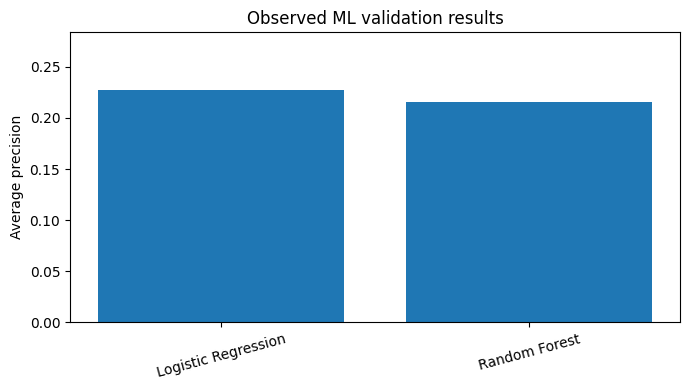

Saved: /content/work/figures/capstone_ml_results.png


In [4]:
# Show the ML comparison without inventing a baseline value.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(model_results["model"], model_results["average_precision"])
ax.set_ylabel("Average precision")
ax.set_title("Observed ML validation results")
ax.set_ylim(0, max(model_results["average_precision"]) * 1.25)
plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig(FIGURES / "capstone_ml_results.png", dpi=160)
plt.show()

print("Saved:", FIGURES / "capstone_ml_results.png")


## 5. Limitations

This work has several important limits:

- The model score is a **directional prioritization signal**, not a guarantee that a page will decline.
- A high score does not prove that refreshing the page will improve traffic, rankings, or SEO performance.
- The future-decline label is a proxy for an observed performance outcome, not a causal measure of refresh ROI.
- Reason codes explain review cues; they are not causal explanations.
- Validation results are evidence for the tested data/split, not a universal guarantee across every future client or time period.
- Search demand, seasonality, algorithm changes, competition, and measurement noise can affect observed performance.
- The model cannot see editorial, legal, strategic, or business context.

All public claims should therefore use terms such as **observed, measured, directional, and decision-support**.


## 6. Ranked recommendations

The model output should become a **human-reviewed content action queue**.

### Suggested action logic

| Signal pattern | Suggested human action |
|---|---|
| Stale + visible + slipping | Review for a possible refresh/update |
| Visible + slipping but not especially stale | Investigate intent, position, and content fit |
| Stale + stable | Monitor rather than automatically changing |
| Low-volume / weak evidence | Deprioritize or manually investigate |
| Strong/healthy performance | Protect and monitor rather than force a refresh |

### Reason codes

Examples of public-safe reason codes are:

- `STALE` — content is materially old at the decision snapshot.
- `VISIBLE_VOLUME` — enough measured visibility exists for review context.
- `POSITION_SLIP` — measured position worsened versus the comparison window.
- `HIGH_DECLINE_SIGNAL` — the model assigns a higher directional probability to the future-decline proxy.
- `LOW_SEARCH_VOLUME` — low demand makes the signal less reliable and calls for caution.

### What should NOT be automated

The system should not automatically rewrite, publish, delete, merge, prune, or otherwise change content. It should also not claim that an action will increase rankings or traffic.

A human should review the page, intent, business context, evidence quality, and proposed action before anything is changed.


In [5]:
# Generate a safe, illustrative action-logic table for the paper.
# Real row-level queue data is intentionally not fabricated in this capstone.
recommendations = pd.DataFrame([
    ["Stale + visible + slipping", "Review for refresh/update", "STALE;VISIBLE_VOLUME;POSITION_SLIP"],
    ["Visible + slipping", "Investigate intent and content fit", "VISIBLE_VOLUME;POSITION_SLIP"],
    ["Stale + stable", "Monitor and review when useful", "STALE"],
    ["Low-volume evidence", "Deprioritize or manually investigate", "LOW_SEARCH_VOLUME"],
    ["Strong/healthy performance", "Protect and monitor", "NO_REFRESH_SIGNAL"],
], columns=["archetype", "suggested_action", "reason_codes"])

recommendations.to_csv(OUTPUTS / "capstone_recommendation_logic.csv", index=False)
recommendations


,archetype,suggested_action,reason_codes
0,Stale + visible + slipping,Review for refresh/update,STALE;VISIBLE_VOLUME;POSITION_SLIP
1,Visible + slipping,Investigate intent and content fit,VISIBLE_VOLUME;POSITION_SLIP
2,Stale + stable,Monitor and review when useful,STALE
3,Low-volume evidence,Deprioritize or manually investigate,LOW_SEARCH_VOLUME
4,Strong/healthy performance,Protect and monitor,NO_REFRESH_SIGNAL


## 7. Artifacts the paper embeds

The deployed paper should reuse:

1. the observed model-results figure;
2. the action/recommendation mapping;
3. the committed notebooks and metric receipts that make the analysis traceable.

The row-level action queue should be regenerated from the approved data workflow and kept out of Git when the repository's leak guard requires that treatment.


In [6]:
# Compact artifact manifest for reproducibility.
manifest = {
    "model_comparison": {
        "logistic_regression_average_precision": 0.227,
        "random_forest_average_precision": 0.216,
        "selection_reason": "Logistic Regression had the higher observed validation average precision."
    },
    "public_safe_scope": {
        "client_names": False,
        "domains_or_urls": False,
        "raw_private_queries": False,
        "credentials": False
    },
    "paper_artifacts": [
        "work/figures/capstone_ml_results.png",
        "work/outputs/capstone_recommendation_logic.csv"
    ]
}
(OUTPUTS / "capstone_metrics.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(json.dumps(manifest, indent=2))


{
  "model_comparison": {
    "logistic_regression_average_precision": 0.227,
    "random_forest_average_precision": 0.216,
    "selection_reason": "Logistic Regression had the higher observed validation average precision."
  },
  "public_safe_scope": {
    "client_names": false,
    "domains_or_urls": false,
    "raw_private_queries": false,
    "credentials": false
  },
  "paper_artifacts": [
    "work/figures/capstone_ml_results.png",
    "work/outputs/capstone_recommendation_logic.csv"
  ]
}


## Acknowledgments & data credit

**Built on the FlyRank ML Internship dataset.**

The dataset and internship project context were provided through the FlyRank ML Internship program. Data credit: https://flyrank.ai


## Reproducibility

The supporting work is organized in the repository under `work/`.

Relevant artifacts include:

- `work/notebooks/w05_*.ipynb` — Week-5 model work
- `work/notebooks/w06_validation_audit.ipynb` — validation/leakage audit
- `work/notebooks/w07_action_playbook.ipynb` — ranked action playbook
- `work/notebooks/capstone.ipynb` — this capstone analysis

The deployed paper should link back to the repository and these notebooks so another reader can inspect the analysis path.


## ML-12 — 5-minute demo outline

1. State the decision problem: prioritize pages for human content-refresh review.
2. Show the key pre-decision features and explain why they are available at decision time.
3. Show the honest validation design and the observed Logistic Regression vs Random Forest results.
4. Show the ranked recommendation logic and reason codes.
5. Explain the limitations and the human-review boundary.

### Social-post cut

I built a content opportunity scoring workflow during my FlyRank ML internship. I compared simple and ML approaches, audited the validation design for leakage, and turned the validated output into a human-reviewed action playbook. The result is a decision-support workflow rather than an automated SEO system.

### Employer-facing summary

I worked on an ML ranking problem that prioritizes pages for content-refresh review. I learned to compare a transparent baseline with ML models, validate under a more honest split, audit for leakage, and translate model output into practical recommendations. The strongest lesson was that a useful model needs honest validation and a clear human decision process around it.


## Self-check

- [x] Research question and decision are explicit.
- [x] Data scope and public-safety rules are stated.
- [x] Features, proxy label, baseline, validation and leakage approach are documented.
- [x] Observed ML results are recorded without inventing a baseline metric.
- [x] Results are framed cautiously.
- [x] Limitations are explicit.
- [x] Ranked recommendations and reason codes are included.
- [x] Human review and no-go automation cases are explicit.
- [x] Paper artifacts are generated under `work/`.
- [x] FlyRank data credit is included.
- [ ] Run the notebook top-to-bottom in the repository environment with the approved data/metric receipts available.
- [ ] Deploy the research paper and put its exact public URL in `submission/paper_url.txt`.
